In [4]:
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

dataset = loadtxt('parkinsons\\telemonitoring\\parkinsons_updrs.data', delimiter=',', skiprows=1)

In [5]:
# dividimos en x como variables de entrada y como variable de salida
X = dataset[:,0:8]
y = dataset[:,8]

In [7]:
# Ver contenido de la columna 1 (índice 0)
import numpy as np
col1 = dataset[:, 0]
print("Columna 1 (subject#):")
print(f"- Valores únicos: {np.unique(col1)}")
print(f"- Cantidad de valores únicos: {len(np.unique(col1))}")
print(f"- Valor mínimo: {col1.min()}")
print(f"- Valor máximo: {col1.max()}")
print(f"- Primeros 20 valores: {col1[:20]}")

Columna 1 (subject#):
- Valores únicos: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42.]
- Cantidad de valores únicos: 42
- Valor mínimo: 1.0
- Valor máximo: 42.0
- Primeros 20 valores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
# escalar los datos
from sklearn.model_selection import RandomizedSearchCV


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Crear el modelo de red neuronal (MLPClassifier)
mlp = MLPClassifier (max_iter=15000)
param_grid = {"hidden_layer_sizes": [(8, 16, 32)], "activation" : ["relu", "tanh"],"alpha": [0.001, 0.01, 0.1]}

grid_search = RandomizedSearchCV(mlp, param_grid, cv=3, n_jobs= -1, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
grid_search.best_params_


c:\Users\MARIA CORREA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'hidden_layer_sizes': (8, 16, 32), 'alpha': 0.001, 'activation': 'relu'}

In [ ]:
# Entrenando la red neuronal
mlp.fit(X_train_scaled, y_train)

# Hacer predicciones 
y_pred = mlp.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.6796536796536796

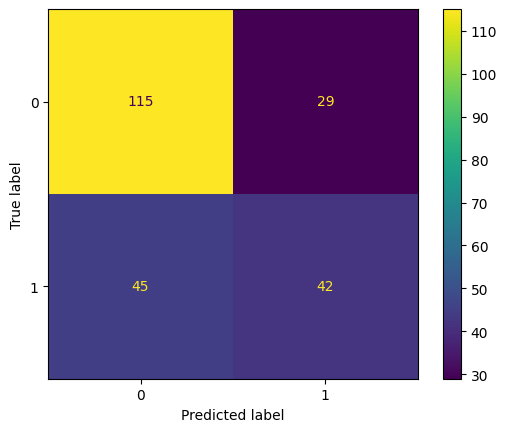

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
conf_matrix.plot()
plt.show()